## GWO Validation on Four Benchmark Functions (PSO Parameter Mapping)

- Functions: Rastrigin, Styblinski-Tang, Ackley, Griewank
- dim 10: population size 30, iterations 1000
- dim 30: population size 30, iterations 1000
- dim 50: population size 30, iterations 1000

<!-- notebook-role-marker -->
## Notebook Role
This notebook is the final algorithm for the report: GWO_hybrid0.3. It combines group-based leader selection with delayed omega birth-death renewal activated after 30% of the maximum iterations.

Unified run setting for all result tables: seed rule `BASE_SEED + run`, population size 30, 1000 iterations, 10 independent runs, dimensions 10/30/50, bounds [-5, 5], and the same success criteria for all benchmark functions.

<!-- final-algorithm-marker -->
## Final Algorithm for the Report
The final algorithm is `GWO_hybrid0.3.ipynb`.

Report name suggestion: Group-Renewal Grey Wolf Optimizer (GR-GWO), implemented as `GWO_hybrid0.3`.

Final-method logic:
- Group leadership: alpha is the current best agent, while beta and delta are sampled from ranked leader groups instead of being fixed single agents.
- Delayed omega renewal: after `0.3 * max_iters`, agents that remain omega for `0.05 * max_iters` are renewed.
- Renewal rule: the new agent is generated around a roulette-selected leader with a Levy-flight displacement.
- Use this notebook's result table, Ackley table, and saved graph as the final numbers for the report.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# PSO -> GWO parameter mapping (keep current PSO scale)
# MAX_VELOCITY -> GWO_RANDOM_STEP (local random perturbation amplitude)
# C1 -> GWO_A0 (initial exploration coefficient a)
# C2 -> GWO_NOISE_SCALE (perturbation scaling)
MAX_VELOCITY = 1.0
BOUNDS = [-5, 5]
C1 = 1
C2 = 1
GWO_RANDOM_STEP = MAX_VELOCITY
GWO_A0 = 2.0 * C1
GWO_NOISE_SCALE = 0.03 * C2

In [3]:
def rastrigin(x: np.ndarray) -> float:
    # A = 10, global minimum at x = 0 with f(x) = 0
    a = 10
    n = len(x)
    return a * n + np.sum(x**2 - a * np.cos(2 * np.pi * x))


def styblinski_tang(x: np.ndarray) -> float:
    # Global minimum at x_i ~= -2.903534 with f(x) ~= -39.16617 * n
    return 0.5 * np.sum(x**4 - 16 * x**2 + 5 * x)


def ackley(x: np.ndarray) -> float:
    # Global minimum at x = 0 with f(x) = 0
    n = len(x)
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(np.sum(x**2) / n))
    term2 = -np.exp(np.sum(np.cos(2 * np.pi * x)) / n)
    return term1 + term2 + 20.0 + np.e


def griewank(x: np.ndarray) -> float:
    # Global minimum at x = 0 with f(x) = 0
    i = np.arange(1, len(x) + 1)
    return np.sum(x**2) / 4000.0 - np.prod(np.cos(x / np.sqrt(i))) + 1.0

In [4]:
import math

class GWO:
    def __init__(self, objective, dim=2, num_particles=30, max_iters=200):
        self.objective = objective
        self.dim = dim
        self.num_particles = num_particles
        self.max_iters = max_iters
        self.leader_group_size = max(1, int(np.ceil(0.1 * num_particles)))

        self.positions = np.random.uniform(BOUNDS[0], BOUNDS[1], (num_particles, dim))
        self.history = []

        self.alpha_pos = None
        self.alpha_score = float("inf")

        self.particle_ids = np.arange(num_particles)
        self.omega_streak = np.zeros(num_particles, dtype=int)
        self.omega_drop_threshold = max(1, math.ceil(0.05 * self.max_iters))
        self.drop_activation_iter = max(0, math.ceil(0.3 * self.max_iters))
        self.drop_count = 0

    @staticmethod
    def _levy_flight_step(dim, beta=1.5):
        sigma_u = (
            (math.gamma(1 + beta) * np.sin(np.pi * beta / 2))
            / (math.gamma((1 + beta) / 2) * beta * (2 ** ((beta - 1) / 2)))
        ) ** (1 / beta)
        u = np.random.normal(0, sigma_u, dim)
        v = np.random.normal(0, 1, dim)
        return u / (np.abs(v) ** (1 / beta) + 1e-12)

    @staticmethod
    def _leader_roulette_index(leader_fitness):
        # Minimization: smaller fitness gets larger weight.
        max_fit = np.max(leader_fitness)
        weights = (max_fit - leader_fitness) + 1e-12
        probs = weights / np.sum(weights)
        return np.random.choice(len(leader_fitness), p=probs)

    def _slice_group(self, start, end, fallback):
        group = self.positions[start:min(end, self.num_particles)]
        return group if len(group) > 0 else fallback

    def _group_representative(self, group):
        rep_idx = np.random.randint(len(group))
        return group[rep_idx].copy()

    def optimize(self):
        for t in range(self.max_iters):
            fitness = np.apply_along_axis(self.objective, 1, self.positions)
            sorted_idx = np.argsort(fitness)
            self.positions = self.positions[sorted_idx]
            fitness = fitness[sorted_idx]
            self.particle_ids = self.particle_ids[sorted_idx]

            # alpha fixed as global best particle
            alpha = self.positions[0].copy()

            # beta / delta sampled from their groups
            beta_group = self._slice_group(
                self.leader_group_size, 2 * self.leader_group_size, self.positions[:1]
            )
            delta_group = self._slice_group(
                2 * self.leader_group_size, 3 * self.leader_group_size, beta_group
            )

            beta = self._group_representative(beta_group)
            delta = self._group_representative(delta_group)

            if fitness[0] < self.alpha_score:
                self.alpha_score = float(fitness[0])
                self.alpha_pos = self.positions[0].copy()

            progress = t / max(1, self.max_iters - 1)
            a = GWO_A0 * (1.0 - progress)

            leaders = [alpha, beta, delta][: min(3, self.num_particles)]
            leader_fitness = fitness[: len(leaders)]
            drop_mechanism_active = t >= self.drop_activation_iter

            for i in range(self.num_particles):
                pid = self.particle_ids[i]

                if drop_mechanism_active:
                    if i >= 3:
                        self.omega_streak[pid] += 1
                    else:
                        self.omega_streak[pid] = 0
                else:
                    self.omega_streak[pid] = 0

                if drop_mechanism_active and self.omega_streak[pid] >= self.omega_drop_threshold:
                    base_idx = self._leader_roulette_index(leader_fitness)
                    base_pos = leaders[base_idx]
                    levy_step = self._levy_flight_step(self.dim)
                    new_pos = base_pos + levy_step * GWO_RANDOM_STEP
                    self.positions[i] = np.clip(new_pos, BOUNDS[0], BOUNDS[1])
                    self.omega_streak[pid] = 0
                    self.drop_count += 1
                    continue

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A1 = 2.0 * a * r1 - a
                C1v = 2.0 * r2
                D_alpha = np.abs(C1v * alpha - self.positions[i])
                X1 = alpha - A1 * D_alpha

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A2 = 2.0 * a * r1 - a
                C2v = 2.0 * r2
                D_beta = np.abs(C2v * beta - self.positions[i])
                X2 = beta - A2 * D_beta

                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)
                A3 = 2.0 * a * r1 - a
                C3v = 2.0 * r2
                D_delta = np.abs(C3v * delta - self.positions[i])
                X3 = delta - A3 * D_delta

                new_pos = (X1 + X2 + X3) / 3.0
                perturb = np.random.uniform(
                    -GWO_RANDOM_STEP, GWO_RANDOM_STEP, self.dim
                ) * GWO_NOISE_SCALE * (1.0 - progress)
                self.positions[i] = np.clip(new_pos + perturb, BOUNDS[0], BOUNDS[1])

            self.history.append(self.alpha_score)

        return self.alpha_pos, self.alpha_score, np.array(self.history)

In [5]:
# Reproducibility
import time

BASE_SEED = 42
NUM_RUNS = 10

dim_list = [10, 30, 50]

# Dimension-wise GWO settings (same scale as original PSO setup)
GWO_SETTINGS = {
    10: {"num_particles": 30, "max_iters": 1000},
    30: {"num_particles": 30, "max_iters": 1000},
    50: {"num_particles": 30, "max_iters": 1000},
}

# Test functions
functions = {
    "Rastrigin": rastrigin,
    "Styblinski-Tang": styblinski_tang,
    "Ackley": ackley,
    "Griewank": griewank,
}

# Success criteria
RAS_TOL_PER_DIM = 1e-2
ST_TOL_PER_DIM = 5e-1
ST_OPTIMUM_PER_DIM = -39.16616570377142
ACKLEY_TOL = 1e-2
GRIEWANK_TOL = 1e-2

def is_success(fname: str, best_value: float, dim: int) -> bool:
    if fname == "Rastrigin":
        return best_value <= (RAS_TOL_PER_DIM * dim)
    if fname == "Styblinski-Tang":
        target = ST_OPTIMUM_PER_DIM * dim
        return abs(best_value - target) <= (ST_TOL_PER_DIM * dim)
    if fname == "Ackley":
        return best_value <= ACKLEY_TOL
    if fname == "Griewank":
        return best_value <= GRIEWANK_TOL
    return False

results = {fname: {} for fname in functions}

for d in dim_list:
    num_particles = GWO_SETTINGS[d]["num_particles"]
    max_iters = GWO_SETTINGS[d]["max_iters"]

    for fname, fobj in functions.items():
        run_best = []
        run_hist = []
        run_time = []

        for run in range(NUM_RUNS):
            seed = BASE_SEED + run
            random.seed(seed)
            np.random.seed(seed)

            t0 = time.perf_counter()
            gwo = GWO(fobj, dim=d, num_particles=num_particles, max_iters=max_iters)
            best_x, best_f, hist = gwo.optimize()
            t1 = time.perf_counter()

            run_best.append(best_f)
            run_hist.append(hist)
            run_time.append(t1 - t0)

        run_best = np.array(run_best)
        run_hist = np.array(run_hist)
        run_time = np.array(run_time)

        success = np.array([is_success(fname, v, d) for v in run_best])

        results[fname][d] = {
            "best": float(np.min(run_best)),
            "mean": float(np.mean(run_best)),
            "std": float(np.std(run_best)),
            "worst": float(np.max(run_best)),
            "success_rate": float(np.mean(success) * 100.0),
            "time_mean_sec": float(np.mean(run_time)),
            "history": np.mean(run_hist, axis=0),
        }

GWO_hybrid0.3.ipynb:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  {
=== Rastrigin (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000000	0.000001	0.000001	0.000002	100.0		4.0988
30	0.000051	0.000075	0.000015	0.000095	100.0		4.4536
50	0.000245	0.000523	0.000151	0.000795	100.0		4.4307

=== Styblinski-Tang (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	-363.387671	-336.012717	18.616315	-302.452723	0.0		4.3777
30	-760.386662	-623.297056	67.026394	-516.436638	0.0		4.5793
50	-1146.249941	-970.540325	94.240241	-843.804620	0.0		4.6953

=== Ackley (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000068	0.000096	0.000015	0.000120	100.0		4.5943
30	0.000304	0.000413	0.000088	0.000635	100.0		4.7456
50	0.000717	0.000888	0.000127	0.001095	100.0		4.8099

=== Griewank (10 runs) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000000	0.006559	0.012091	0.041142	90.0		4.6382

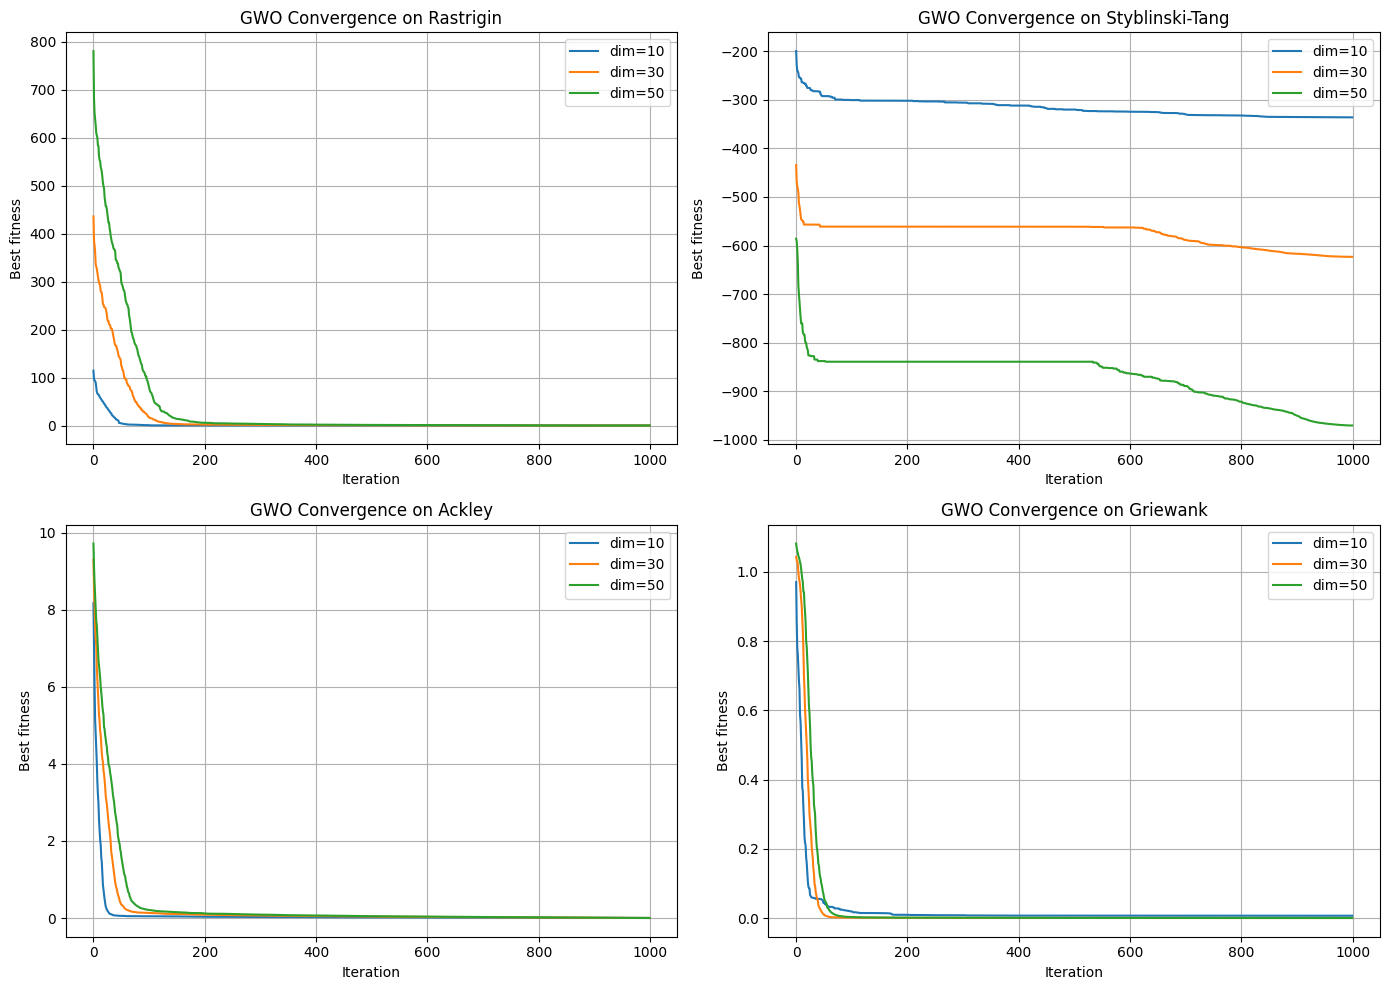

In [6]:
# Plot results for all four functions and save report-ready convergence figures
from pathlib import Path

ASSET_DIR = Path("assets")
ASSET_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, fname in enumerate(functions.keys()):
    ax = axes[idx]
    for d in dim_list:
        ax.plot(results[fname][d]["history"], label=f"dim={d}")
    ax.set_title(f"GWO_hybrid0.3 Convergence on {fname}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best fitness")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
combined_path = ASSET_DIR / "convergence_all_functions_gwo_hybrid0.3.png"
fig.savefig(combined_path, dpi=200, bbox_inches="tight")
plt.show()

function_file_names = {
    "Rastrigin": "rastrigin_convergence_gwo_hybrid0.3.png",
    "Styblinski-Tang": "styblinski_tang_convergence_gwo_hybrid0.3.png",
    "Ackley": "ackley_convergence_gwo_hybrid0.3.png",
    "Griewank": "griewank_convergence_gwo_hybrid0.3.png",
}

for fname in functions.keys():
    fig_single, ax = plt.subplots(figsize=(8, 5))
    for d in dim_list:
        ax.plot(results[fname][d]["history"], label=f"dim={d}")
    ax.set_title(f"{fname} Convergence - Final Algorithm (GWO_hybrid0.3)")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best fitness")
    ax.grid(True)
    ax.legend()
    fig_single.tight_layout()
    fig_single.savefig(ASSET_DIR / function_file_names[fname], dpi=200, bbox_inches="tight")
    plt.close(fig_single)

print(f"Saved combined convergence graph to: {combined_path}")
for fname, file_name in function_file_names.items():
    print(f"Saved {fname} convergence graph to: {ASSET_DIR / file_name}")
print()

for fname in functions.keys():
    print(f"=== {fname} ({NUM_RUNS} runs) ===")
    print("dim	best		mean		std		worst		success_rate(%)	mean_time(s)")
    for d in dim_list:
        s = results[fname][d]
        print(f"{d}	{s['best']:.6f}	{s['mean']:.6f}	{s['std']:.6f}	{s['worst']:.6f}	{s['success_rate']:.1f}		{s['time_mean_sec']:.4f}")
    print()


=== Ackley Result Table: Final Algorithm (GWO_hybrid0.3) ===
dim	best		mean		std		worst		success_rate(%)	mean_time(s)
10	0.000068	0.000096	0.000015	0.000120	100.0		4.5943
30	0.000304	0.000413	0.000088	0.000635	100.0		4.7456
50	0.000717	0.000888	0.000127	0.001095	100.0		4.8099
GWO_hybrid0.3.ipynb:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "    a = 10\n",
Saved Ackley table to: assets\ackley_gwo_hybrid0.3_table.csv
Saved all final-method results to: assets\gwo_hybrid0.3_all_results.csv
Saved Ackley convergence graph to: assets\ackley_convergence_gwo_hybrid0.3.png
Saved unified settings to: assets\unified_experiment_settings.txt


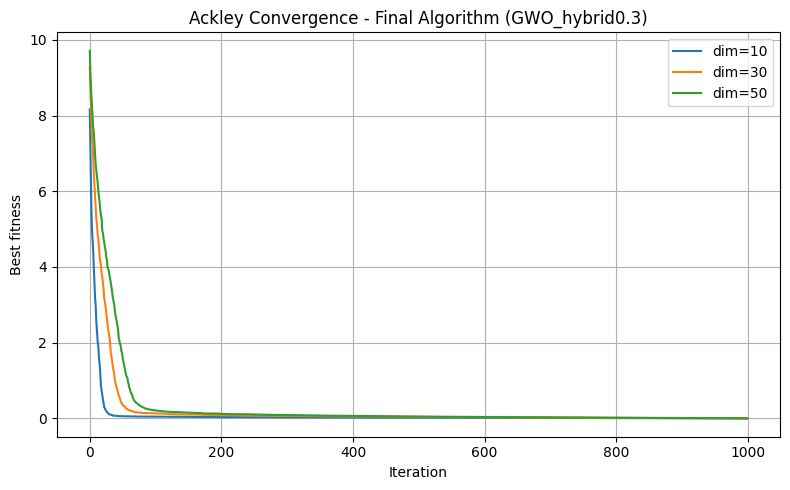

In [7]:
# REPORT_EXPORT_ACKLEY_MARKER
# Dedicated Ackley table and convergence graph for the final report.
# This cell uses the unified `results` dictionary produced above.
from pathlib import Path
import csv

REPORT_ASSET_DIR = Path("assets")
REPORT_ASSET_DIR.mkdir(exist_ok=True)

ackley_rows = []
for d in dim_list:
    s = results["Ackley"][d]
    ackley_rows.append({
        "algorithm": "GWO_hybrid0.3",
        "function": "Ackley",
        "dim": d,
        "best": s["best"],
        "mean": s["mean"],
        "std": s["std"],
        "worst": s["worst"],
        "success_rate_percent": s["success_rate"],
        "mean_time_sec": s["time_mean_sec"],
    })

ackley_csv = REPORT_ASSET_DIR / "ackley_gwo_hybrid0.3_table.csv"
with ackley_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(ackley_rows[0].keys()))
    writer.writeheader()
    writer.writerows(ackley_rows)

all_rows = []
for fname in functions.keys():
    for d in dim_list:
        s = results[fname][d]
        all_rows.append({
            "algorithm": "GWO_hybrid0.3",
            "function": fname,
            "dim": d,
            "best": s["best"],
            "mean": s["mean"],
            "std": s["std"],
            "worst": s["worst"],
            "success_rate_percent": s["success_rate"],
            "mean_time_sec": s["time_mean_sec"],
        })

all_csv = REPORT_ASSET_DIR / "gwo_hybrid0.3_all_results.csv"
with all_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()))
    writer.writeheader()
    writer.writerows(all_rows)

settings_txt = REPORT_ASSET_DIR / "unified_experiment_settings.txt"
settings_txt.write_text(
    "Final algorithm: GWO_hybrid0.3\n"
    "Python: 3.10.11\n"
    "NumPy: 1.26.4\n"
    "Matplotlib: 3.10.8\n"
    "BASE_SEED: 42; seed per run: BASE_SEED + run\n"
    "Population size: 30; iterations: 1000; runs: 10; dimensions: 10, 30, 50\n"
    "Bounds: [-5, 5]\n"
    "Functions: Rastrigin, Styblinski-Tang, Ackley, Griewank\n"
    "Success criteria: Rastrigin <= 1e-2 * dim; Styblinski-Tang within 5e-1 * dim of -39.16616570377142 * dim; Ackley <= 1e-2; Griewank <= 1e-2\n",
    encoding="utf-8",
)

print("=== Ackley Result Table: Final Algorithm (GWO_hybrid0.3) ===")
print("dim\tbest\t\tmean\t\tstd\t\tworst\t\tsuccess_rate(%)\tmean_time(s)")
for row in ackley_rows:
    print(
        f"{row['dim']}\t{row['best']:.6f}\t{row['mean']:.6f}\t"
        f"{row['std']:.6f}\t{row['worst']:.6f}\t"
        f"{row['success_rate_percent']:.1f}\t\t{row['mean_time_sec']:.4f}"
    )

fig, ax = plt.subplots(figsize=(8, 5))
for d in dim_list:
    ax.plot(results["Ackley"][d]["history"], label=f"dim={d}")
ax.set_title("Ackley Convergence - Final Algorithm (GWO_hybrid0.3)")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best fitness")
ax.grid(True)
ax.legend()
fig.tight_layout()
ackley_png = REPORT_ASSET_DIR / "ackley_convergence_gwo_hybrid0.3.png"
fig.savefig(ackley_png, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved Ackley table to: {ackley_csv}")
print(f"Saved all final-method results to: {all_csv}")
print(f"Saved Ackley convergence graph to: {ackley_png}")
print(f"Saved unified settings to: {settings_txt}")

<!-- anti-derivative-proof-marker -->
## Anti-Derivative Proof
This section explains why `GWO_hybrid0.3` is not a simple derivative of PSO, ACO, GA, or the original GWO.

Compared with PSO, the method has no velocity vector and no personal-best memory. Agents are not moved by accumulated momentum toward personal/global bests; they are repositioned by group leader references and, when stagnating as omega, renewed by a birth-death rule.

Compared with ACO, the method has no pheromone matrix, no path construction process, and no pheromone evaporation/reinforcement cycle. Communication is ranking-based through alpha/beta/delta groups and roulette leader selection during renewal.

Compared with GA, the method does not use crossover, mutation, chromosome selection, or generational reproduction as its main search operator. Poorly ranked omega agents are replaced only after a sustained low-rank streak, and the replacement is generated by Levy-flight displacement around a selected leader.

Compared with original GWO, the interaction logic is changed in two ways. First, beta and delta are not fixed single best wolves; they are sampled from leader groups, reducing dependence on the top three agents. Second, long-term omega agents are actively renewed after 30% of the search process, adding a rank-history-based escape mechanism that original GWO does not contain.

<!-- reproducibility-marker -->
## Reproducibility and Notebook Usage
Unified environment and run settings:
- Python 3.10.11
- NumPy 1.26.4
- Matplotlib 3.10.8
- `BASE_SEED = 42`; run seed is `BASE_SEED + run`
- Population size: 30 agents
- Maximum iterations: 1000
- Independent runs: 10
- Dimensions: 10, 30, 50
- Search bounds: [-5, 5]
- Benchmark functions: Rastrigin, Styblinski-Tang, Ackley, Griewank
- Success criteria: Rastrigin <= `1e-2 * dim`; Styblinski-Tang within `5e-1 * dim` of `-39.16616570377142 * dim`; Ackley <= `1e-2`; Griewank <= `1e-2`

Notebook usage:
- `GWO_original.ipynb`: original GWO baseline.
- `GWO_group.ipynb`: ablation for group-based beta/delta leader sampling.
- `GWO_borndeath.ipynb`: ablation for omega birth-death plus Levy-flight renewal.
- `GWO_hybrid.ipynb`: group-leadership draft/ablation; not the final method.
- `GWO_hybrid0.3.ipynb`: final proposed algorithm and final report results.

Saved report assets generated by this notebook:
- `assets/ackley_gwo_hybrid0.3_table.csv`
- `assets/gwo_hybrid0.3_all_results.csv`
- `assets/ackley_convergence_gwo_hybrid0.3.png`
- `assets/unified_experiment_settings.txt`